# Exercise: Sequence-to-Sequence on Real Text
## AIAT 122 - Deep Learning

## Learning Objectives

- Implement a transformer **encoder–decoder**
- Train a sequence-to-sequence model on **real sentences**
- Evaluate generated text with **BLEU**
- Understand why the data you train on decides what the model can possibly learn

## Real-World Context

A production seq2seq system — translation, summarisation, speech transcription — is trained on a
**parallel corpus**: pairs of sequences that mean the same thing. This machine has no translation
corpus on it, and inventing one with `torch.randint` would teach you nothing: a model that maps
random integers to random integers has no signal to find, and every loss curve it produces is
meaningless.

So this exercise uses a real corpus we *do* have — **50,000 genuine IMDB movie reviews** — and a
real sequence-to-sequence task that pairs sequences honestly: **denoising**. We take a real
sentence, corrupt 30% of its words into `<unk>`, and ask your model to reconstruct the original.

Sketch of the idea (the data cell below prints a real pair straight from the corpus):

- Source: `please give this one a <unk> br br <unk> and the <unk> of the cast rendered terrible <unk>`
- Target: `please give this one a miss br br <unk> and the rest of the cast rendered terrible performances`

That is exactly the objective BART is pretrained with (Lewis et al., 2020), it is the same
encoder–decoder architecture translation uses, and every number you report will be about real
English rather than about noise.


## 📥 Inputs & 📤 Outputs

**Inputs:** PyTorch and the **IMDB movie-review dataset**, which is cached locally with Keras —
no download and no network needed. Reviews arrive already tokenised to integer word ids.

**Outputs:** What you'll see when you run the cells

- The real corpus: number of pairs, sequence lengths, and one corrupted/clean pair printed as English
- Your model's architecture and its output shape on a **real** batch
- Training loss, and BLEU between your reconstructions and the true sentences

**Expected:** When complete you should see a working encoder–decoder, a falling loss on real text,
and BLEU scores on held-out sentences — reported next to the trivial baseline of "copy the
corrupted input straight through". Compare with the instructor solution after the deadline.

---


## The real data (run this first)

This cell is complete — read it, then run it. It builds the (corrupted → clean) pairs every task
below uses.

**Why the corruption is legitimate here.** The random masking is noise deliberately injected *into
a real dataset* to create the task, which is the standard denoising objective. The sentences
themselves are real; nothing about the language is invented.


In [1]:
# WHAT: load real IMDB reviews and build (corrupted sentence -> original sentence) pairs.
# WHY: a seq2seq model needs PAIRS. Denoising manufactures honest pairs from a real corpus,
#      so the model has real English structure to learn instead of random integers.
%pip install torch -q

import numpy as np
import torch
from tensorflow import keras          # used only to load the locally cached IMDB dataset

torch.manual_seed(0)
rng = np.random.default_rng(0)

VOCAB_SIZE = 5_000     # keep the 5k most frequent words
SEQ_LEN = 40           # take the first 40 words of each review - short enough to train quickly
MASK_RATE = 0.30       # corrupt 30% of the source tokens

# Keras reserves ids 0-3, so we reuse them as our special tokens - no re-indexing needed.
PAD, SOS, UNK, EOS = 0, 1, 2, 3

(train_raw, _), (test_raw, _) = keras.datasets.imdb.load_data(num_words=VOCAB_SIZE)

def build_pairs(reviews, n_pairs):
    """Return (corrupted_source, clean_target) tensors built from real reviews."""
    long_enough = [r for r in reviews if len(r) >= SEQ_LEN + 1][:n_pairs]
    clean = np.array([r[1:SEQ_LEN + 1] for r in long_enough], dtype=np.int64)  # drop the <start> id
    corrupted = clean.copy()
    mask = rng.random(clean.shape) < MASK_RATE
    corrupted[mask] = UNK                                   # this is the injected noise
    # Target sequence for the decoder: <sos> ... sentence ... <eos>
    target = np.concatenate([np.full((len(clean), 1), SOS, dtype=np.int64),
                             clean,
                             np.full((len(clean), 1), EOS, dtype=np.int64)], axis=1)
    return torch.tensor(corrupted), torch.tensor(target)

src_train, tgt_train = build_pairs(train_raw, 8000)
src_test, tgt_test = build_pairs(test_raw, 1000)
print(f"Real corpus: {len(src_train):,} training pairs, {len(src_test):,} test pairs")
print(f"Source shape {tuple(src_train.shape)}  ->  target shape {tuple(tgt_train.shape)} "
      "(different lengths: the decoder writes <sos> + sentence + <eos>)")
print(f"Actually corrupted: {(src_train == UNK).float().mean() * 100:.1f}% of source tokens "
      "(the review's own <unk> tokens are included in that count)")

# Decode ids back to words so you can see the real task.
word_index = keras.datasets.imdb.get_word_index()
id_to_word = {v + 3: k for k, v in word_index.items()}
id_to_word.update({PAD: "<pad>", SOS: "<sos>", UNK: "<unk>", EOS: "<eos>"})
def to_text(ids):
    return " ".join(id_to_word.get(int(i), "?") for i in ids)

print("\nOne real pair:")
print("  SOURCE (corrupted):", to_text(src_train[0]))
print("  TARGET (original) :", to_text(tgt_train[0]))

# The baseline your model must beat: copy the corrupted source through unchanged.
copy_accuracy = (src_test == tgt_test[:, 1:-1]).float().mean().item()
print(f"\nBaseline 'copy the source through unchanged' already gets "
      f"{copy_accuracy * 100:.1f}% of tokens right,")
print("because only ~30% of them were corrupted. Any score you report must be compared to this.")


Note: you may need to restart the kernel to use updated packages.


Real corpus: 8,000 training pairs, 1,000 test pairs
Source shape (8000, 40)  ->  target shape (8000, 42) (different lengths: the decoder writes <sos> + sentence + <eos>)
Actually corrupted: 36.2% of source tokens (the review's own <unk> tokens are included in that count)

One real pair:
  SOURCE (corrupted): this <unk> <unk> <unk> brilliant casting location scenery story direction everyone's <unk> suited <unk> part <unk> played and <unk> could <unk> <unk> being there robert <unk> is an amazing actor and now <unk> same being director <unk> father came from
  TARGET (original) : <sos> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <unk> is an amazing actor and now the same being director <unk> father came from <eos>

Baseline 'copy the source through unchanged' already gets 72.5% of tokens right,
because only ~30% of them were corrupted. Any score you report must be compared

## Task 1: Transformer Architecture (35 points)

Implement a transformer encoder–decoder for the denoising task:
1. Encoder with self-attention over the corrupted sentence
2. Decoder with masked self-attention plus cross-attention to the encoder
3. Positional encoding (attention alone is order-blind)


In [2]:
import torch.nn as nn
import math

# ── Task 1: Transformer Architecture ────────────────────────────────────────
# Hint: nn.Transformer already contains both stacks. You supply the embeddings,
#       the positional encoding, the output projection, and the causal target mask.
# Reference: example 04_transformer_attention.ipynb

class DenoisingTransformer(nn.Module):
    def __init__(self, vocab_size=VOCAB_SIZE, d_model=128, nhead=4, num_layers=2, max_len=64):
        super().__init__()
        # TODO: Embedding + positional encoding (shared between encoder and decoder is fine)
        # self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD)
        # Positional encoding can be a simple lookup table:
        # self.pos_embedding = nn.Embedding(max_len, d_model)

        # TODO: Transformer encoder-decoder
        # self.transformer = nn.Transformer(d_model=d_model, nhead=nhead,
        #                                   num_encoder_layers=num_layers,
        #                                   num_decoder_layers=num_layers,
        #                                   batch_first=True)

        # TODO: Output linear projection to vocabulary
        # self.out_proj = nn.Linear(d_model, vocab_size)
        pass

    def forward(self, src, tgt):
        # TODO: embed src and tgt, add positions, apply the transformer, project to vocab.
        # A causal mask is REQUIRED on the target, or the decoder simply reads the answer:
        # tgt_mask = nn.Transformer.generate_square_subsequent_mask(tgt.size(1))
        # src_emb = self.embedding(src) + self.pos_embedding(torch.arange(src.size(1)))
        # tgt_emb = self.embedding(tgt) + self.pos_embedding(torch.arange(tgt.size(1)))
        # out = self.transformer(src_emb, tgt_emb, tgt_mask=tgt_mask,
        #                        src_key_padding_mask=(src == PAD))
        # return self.out_proj(out)
        pass

# Sanity check on a REAL batch, not on random integers
model = DenoisingTransformer()
print(model)
src = src_train[:2]              # (batch=2, 40) real corrupted sentences
tgt = tgt_train[:2, :-1]         # (batch=2, 41) teacher-forcing input: everything but <eos>
print("src:", to_text(src[0])[:90], "...")
try:
    out = model(src, tgt)
    print("Output shape:", out.shape)   # expect (2, 41, VOCAB_SIZE)
except Exception as e:
    print("Implement forward() first:", e)


DenoisingTransformer()
src: this <unk> <unk> <unk> brilliant casting location scenery story direction everyone's <unk> ...
Implement forward() first: 'NoneType' object has no attribute 'shape'


## Task 2: Training (30 points)

Train the denoising model:
1. Batch the real pairs with a `DataLoader`
2. Train the encoder–decoder with teacher forcing
3. Track loss, and evaluate on the held-out pairs

**Watch for:** ignore `PAD` in the loss, and shift the decoder input/target by one
(`tgt[:, :-1]` in, `tgt[:, 1:]` predicted). Getting that shift wrong is the single most common
bug in this exercise — the loss falls beautifully because the model is copying the answer.


In [3]:
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# ── Task 2: Training ────────────────────────────────────────────────────────
# The real data is already loaded: src_train / tgt_train and src_test / tgt_test.
train_loader = DataLoader(TensorDataset(src_train, tgt_train), batch_size=64, shuffle=True)
print(f"{len(train_loader)} batches of real sentence pairs per epoch")

# TODO: Define loss and optimizer
# criterion = nn.CrossEntropyLoss(ignore_index=PAD)   # never score the padding
# optimizer = optim.Adam(model.parameters(), lr=1e-4)

# TODO: Simple training loop
NUM_EPOCHS = 5

# for epoch in range(NUM_EPOCHS):
#     model.train()
#     total_loss = 0
#     for src_batch, tgt_batch in train_loader:
#         optimizer.zero_grad()
#         # Teacher forcing: feed tgt[:, :-1] as input, predict tgt[:, 1:]
#         logits = model(src_batch, tgt_batch[:, :-1])     # (B, T-1, vocab)
#         loss = criterion(logits.reshape(-1, logits.size(-1)),
#                          tgt_batch[:, 1:].reshape(-1))
#         loss.backward()
#         optimizer.step()
#         total_loss += loss.item()
#     print(f'Epoch {epoch+1}  Loss: {total_loss/len(train_loader):.4f}')

# YOUR CODE HERE
print('Task 2 scaffold ready ✅')


125 batches of real sentence pairs per epoch
Task 2 scaffold ready ✅


## Task 3: Evaluate on Real Sentences (35 points)

Apply your trained model to held-out corrupted reviews.

**Requirements:**
- Run greedy decoding on at least 5 **real** held-out sentences from `src_test`
- Compute **BLEU** against the true sentences (`nltk.translate.bleu_score` is installed — use
  `sentence_bleu` with a smoothing function, since these are short sequences)
- Also compute BLEU for the **copy-the-source baseline** printed in the data cell. Your model has
  to beat that number, not zero
- Show side by side: corrupted source | your reconstruction | original sentence
- Write 2–3 sentences: what it recovered, what it did not, and whether it beat the baseline.
  "It did not beat the baseline" is a fully-credited answer when that is what the numbers say

**Submission**: the completed notebook. **Grading**: 100 points total.


In [4]:
# ── Task 3: Evaluation on real held-out sentences ───────────────────────────
# Hint: greedy decoding starts from <sos> and appends the argmax token each step.
# Reference: example 07_sequence_to_sequence.ipynb (autoregressive rollout)

def greedy_decode(model, src_row, max_len=SEQ_LEN + 2):
    """Reconstruct one sentence token by token (greedy, no teacher forcing)."""
    model.eval()
    with torch.no_grad():
        src = src_row.unsqueeze(0)                 # (1, SEQ_LEN)
        tgt = torch.tensor([[SOS]])                # start token
        for _ in range(max_len):
            # TODO: call model(src, tgt), take the argmax of the LAST position
            # logits = model(src, tgt)
            # next_token = logits[:, -1, :].argmax(-1, keepdim=True)
            # if next_token.item() == EOS: break
            # tgt = torch.cat([tgt, next_token], dim=1)
            break  # remove this once implemented
    return tgt[0]

# TODO: run greedy_decode on 5 real test sentences and print source / output / reference
# for i in range(5):
#     print("SOURCE:", to_text(src_test[i]))
#     print("OUTPUT:", to_text(greedy_decode(model, src_test[i])))
#     print("TRUE  :", to_text(tgt_test[i][1:-1]))

# TODO: BLEU for your model AND for the copy-the-source baseline
# from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
# smooth = SmoothingFunction().method1
# ref = [to_text(tgt_test[i][1:-1]).split()]
# bleu_model = sentence_bleu(ref, to_text(greedy_decode(model, src_test[i])).split(), smoothing_function=smooth)
# bleu_copy  = sentence_bleu(ref, to_text(src_test[i]).split(), smoothing_function=smooth)

# YOUR CODE HERE

# ── Short written analysis ──────────────────────────────────────────────────
print('BLEU (my model) vs BLEU (copy-the-source baseline):')
print('  ...')
print('What it recovered, and what it did not:')
print('  ...')
print('What I would improve next (e.g. beam search, more layers, more data):')
print('  ...')


BLEU (my model) vs BLEU (copy-the-source baseline):
  ...
What it recovered, and what it did not:
  ...
What I would improve next (e.g. beam search, more layers, more data):
  ...


## 🌍 Real-World Worked Example — Does Positional Encoding Actually Help?

**Industry context:**
- **Tweet sentiment is a published benchmark.** TweetEval (Barbieri et al., *Findings of EMNLP 2020*, [arXiv:2010.12421](https://arxiv.org/abs/2010.12421)) bundles seven Twitter classification tasks — sentiment among them — and shows that continuing to train a general pre-trained model on Twitter text beats training from scratch.
- **Amazon publishes the review data and the BERT baseline.** The Multilingual Amazon Reviews Corpus (Keung, Lu, Szarvas & Smith, Amazon, *EMNLP 2020*) holds 200,000 training reviews per language in six languages collected 2015-2019, with reported baselines that fine-tune multilingual BERT.
- **Ticket triage ships as a product.** Zendesk's documentation states that "intelligent triage uses AI to automatically classify new customer support tickets by topic, sentiment, language, and entities, such as product names". Zendesk does not publish the architecture — so assume the task is real, not that it is a transformer.

Positional encoding is presented as non-negotiable: attention is order-blind, so position must be
injected. True — but "necessary in general" is not the same as "helps on your task."

Below we train the same mini-Transformer encoder twice on **real IMDB reviews**, once with the
learned positional embedding and once without it, and we add the oldest baseline in text
classification — **logistic regression on a bag of words**, a model with no notion of order at all.
Read the three numbers before you read the conclusion.


6,000 training reviews, 3,000 test reviews, 50.2% positive -> majority baseline 50.2%


  with positional encoding:    73.8%


  without positional encoding: 75.8%


  bag of words + logistic regression (no order at all): 83.6%

WHAT ACTUALLY HAPPENED: the run WITHOUT positional encoding scored +2.0 points versus the run with it,
and the 95% margin on a single accuracy at n=3,000 is about +/-1.8 points - so the honest reading is 'positions bought us nothing here',
not 'positions hurt'. Meanwhile the order-free bag of words beat BOTH transformer runs by
about 8 points, which is far outside that margin.

Read that carefully, because it is two lessons at once:
1. Positional encoding is architecturally necessary but not automatically USEFUL. This
   task is 'does this review contain positive or negative words', which barely depends on
   order - so the position table is extra parameters to learn from only 6,000 examples.
2. A from-scratch transformer is data-hungry. BERT reaches ~94% on sentiment benchmarks
   because it arrives pretrained on billions of tokens, not because of its shape.
Positions DO matter for your Task 1-3 denoising model: reconstruc

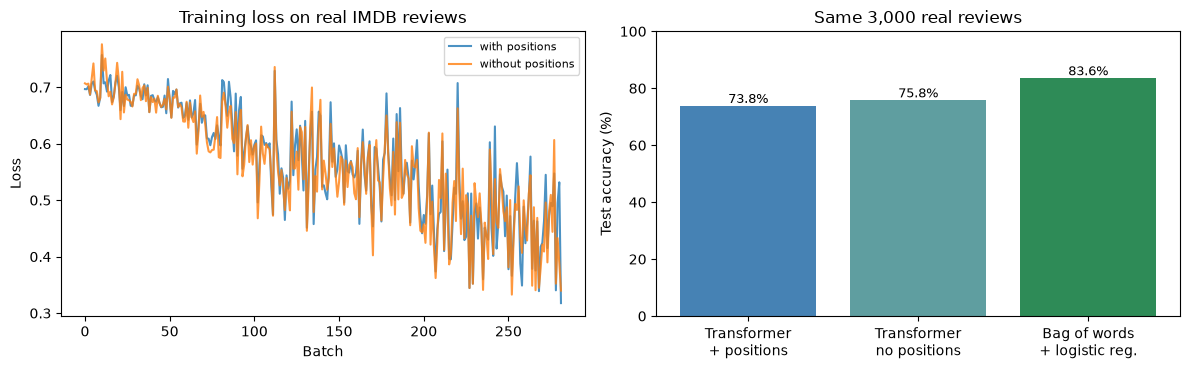

In [5]:
# WHAT: train a mini-Transformer sentiment classifier on real IMDB reviews twice - with and
#       without positional encoding - and compare both to bag-of-words logistic regression.
# WHY: it turns a slogan ('transformers need positions') into a measurement on real data.
import torch, torch.nn as nn, torch.optim as optim
import numpy as np, matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from scipy.sparse import csr_matrix

CLS_SEQ, D_MODEL = 120, 64

# ── Real data: IMDB reviews with their real positive/negative labels ────────
(cls_train_raw, cls_y_train), (cls_test_raw, cls_y_test) = keras.datasets.imdb.load_data(num_words=VOCAB_SIZE)
def cls_pad(seqs):
    return keras.preprocessing.sequence.pad_sequences(
        seqs, maxlen=CLS_SEQ, padding="post", truncating="post")

pick = np.random.default_rng(0)
i_tr = pick.permutation(len(cls_train_raw))[:6000]
i_te = pick.permutation(len(cls_test_raw))[:3000]
Xc_tr = torch.tensor(cls_pad(cls_train_raw[i_tr]), dtype=torch.long)
yc_tr = torch.tensor(cls_y_train[i_tr], dtype=torch.long)
Xc_te = torch.tensor(cls_pad(cls_test_raw[i_te]), dtype=torch.long)
yc_te = torch.tensor(cls_y_test[i_te], dtype=torch.long)
print(f"{len(Xc_tr):,} training reviews, {len(Xc_te):,} test reviews, "
      f"{cls_y_test[i_te].mean() * 100:.1f}% positive -> majority baseline "
      f"{max(cls_y_test[i_te].mean(), 1 - cls_y_test[i_te].mean()) * 100:.1f}%")


class MiniTransformer(nn.Module):
    """Token embedding (+ optional positions) -> 2 Transformer layers -> masked mean-pool -> classify."""
    def __init__(self, use_positions=True):
        super().__init__()
        self.use_positions = use_positions
        self.embed = nn.Embedding(VOCAB_SIZE, D_MODEL, padding_idx=PAD)
        self.pos_enc = nn.Embedding(CLS_SEQ, D_MODEL)      # learnable positional encoding
        layer = nn.TransformerEncoderLayer(d_model=D_MODEL, nhead=4, dim_feedforward=128,
                                           dropout=0.1, batch_first=True)
        self.encoder = nn.TransformerEncoder(layer, num_layers=2, enable_nested_tensor=False)
        self.classifier = nn.Linear(D_MODEL, 2)
    def forward(self, x):
        pad = (x == PAD)
        h = self.embed(x)
        if self.use_positions:
            h = h + self.pos_enc(torch.arange(x.size(1)))
        h = self.encoder(h, src_key_padding_mask=pad)      # never attend to padding
        # Mean-pool over real tokens only, otherwise short reviews are averaged towards zero.
        h = h.masked_fill(pad.unsqueeze(-1), 0.0).sum(1) / (~pad).sum(1, keepdim=True).clamp(min=1)
        return self.classifier(h)


def train_and_score(use_positions):
    torch.manual_seed(42)                       # same init for both runs: only positions differ
    net = MiniTransformer(use_positions)
    opt = optim.Adam(net.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()
    loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(Xc_tr, yc_tr), batch_size=64, shuffle=True)
    curve = []
    for epoch in range(3):
        net.train()
        for xb, yb in loader:
            loss = loss_fn(net(xb), yb)
            opt.zero_grad(); loss.backward(); opt.step()
            curve.append(loss.item())
    net.eval()
    with torch.no_grad():
        acc = (net(Xc_te).argmax(1) == yc_te).float().mean().item()
    return acc, curve

acc_pos, curve_pos = train_and_score(True)
print(f"  with positional encoding:    {acc_pos * 100:.1f}%")
acc_nopos, curve_nopos = train_and_score(False)
print(f"  without positional encoding: {acc_nopos * 100:.1f}%")

# ── Bag of words: a model that cannot represent order at all ────────────────
def bag_of_words(seqs):
    rows, cols = [], []
    for i, s in enumerate(seqs):
        for t in set(s):
            if t < VOCAB_SIZE:
                rows.append(i); cols.append(t)
    return csr_matrix((np.ones(len(rows)), (rows, cols)), shape=(len(seqs), VOCAB_SIZE))

bow = LogisticRegression(max_iter=1000).fit(bag_of_words(cls_train_raw[i_tr]), cls_y_train[i_tr])
acc_bow = (bow.predict(bag_of_words(cls_test_raw[i_te])) == cls_y_test[i_te]).mean()
print(f"  bag of words + logistic regression (no order at all): {acc_bow * 100:.1f}%")

noise_floor = 1.96 * (0.5 / len(yc_te) ** 0.5) * 100
print(f"\nWHAT ACTUALLY HAPPENED: the run WITHOUT positional encoding scored "
      f"{(acc_nopos - acc_pos) * 100:+.1f} points versus the run with it,")
print(f"and the 95% margin on a single accuracy at n={len(yc_te):,} is about "
      f"+/-{noise_floor:.1f} points - so the honest reading is 'positions bought us nothing here',")
print("not 'positions hurt'. Meanwhile the order-free bag of words beat BOTH transformer runs by")
print(f"about {(acc_bow - max(acc_pos, acc_nopos)) * 100:.0f} points, which is far outside that margin.")
print("\nRead that carefully, because it is two lessons at once:")
print("1. Positional encoding is architecturally necessary but not automatically USEFUL. This")
print("   task is 'does this review contain positive or negative words', which barely depends on")
print("   order - so the position table is extra parameters to learn from only 6,000 examples.")
print("2. A from-scratch transformer is data-hungry. BERT reaches ~94% on sentiment benchmarks")
print("   because it arrives pretrained on billions of tokens, not because of its shape.")
print("Positions DO matter for your Task 1-3 denoising model: reconstructing a sentence means")
print("putting words back in the right places. Test that claim rather than assuming it.")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].plot(curve_pos, label="with positions", alpha=0.8)
axes[0].plot(curve_nopos, label="without positions", alpha=0.8)
axes[0].set_title("Training loss on real IMDB reviews")
axes[0].set_xlabel("Batch"); axes[0].set_ylabel("Loss"); axes[0].legend(fontsize=8)
names = ["Transformer\n+ positions", "Transformer\nno positions", "Bag of words\n+ logistic reg."]
vals = [acc_pos * 100, acc_nopos * 100, acc_bow * 100]
axes[1].bar(names, vals, color=["steelblue", "cadetblue", "seagreen"])
for i, v in enumerate(vals):
    axes[1].text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=9)
axes[1].set_ylim(0, 100); axes[1].set_ylabel("Test accuracy (%)")
axes[1].set_title("Same 3,000 real reviews")
plt.tight_layout(); plt.show()


## 📚 References & Further Reading

**Foundational Paper:**
- Vaswani et al. (2017) — [Attention Is All You Need](https://arxiv.org/abs/1706.03762) *(must-read)*

**The task you are implementing:**
- Lewis et al. (2020) — [BART: Denoising Sequence-to-Sequence Pre-training](https://arxiv.org/abs/1910.13461) — corrupt the text, reconstruct the original; the objective used in Tasks 1–3
- Papineni et al. (2002) — [BLEU: a Method for Automatic Evaluation of Machine Translation](https://aclanthology.org/P02-1040/) — the metric, including why it needs a baseline next to it

**Follow-up:**
- Devlin et al. (2018) — [BERT](https://arxiv.org/abs/1810.04805)
- Brown et al. (2020) — [GPT-3](https://arxiv.org/abs/2005.14165)
- Touvron et al. (2023) — [LLaMA](https://arxiv.org/abs/2302.13971)

**Interactive:** [The Illustrated Transformer by Jay Alammar](https://jalammar.github.io/illustrated-transformer/)

**Data source:** IMDB Large Movie Review Dataset — Maas et al. (2011), [Learning Word Vectors for Sentiment Analysis](https://aclanthology.org/P11-1015/). 50,000 real reviews, shipped with Keras and cached locally.

**State-of-the-Art:** modern seq2seq systems are transformers pretrained on enormous corpora and then fine-tuned. The architecture you build here is the same one; the difference is the data, which is exactly the point this notebook keeps making.
